# Étape 7 : Modèles de Machine Learning
Ce notebook illustre l'ajout d'une phase de Machine Learning sur les données enrichies provenant des bulletins ANSSI.

## Chargement des données

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import sys

DATA_PATH = 'cves_concat.csv'

if not Path(DATA_PATH).is_file():
    sys.exit(f" Fichier introuvable : {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# --- Nettoyage des colonnes ---
df.columns = df.columns.str.strip()                   
columns_translation = {                              
    'Score CVSS': 'cvss',
    'Base Severity': 'severity',
    'Score EPSS': 'epss',
    'Description CWE': 'cwe_description'
}
df.rename(columns=columns_translation, inplace=True)
df = df.loc[:, ~df.columns.duplicated()]              

# --- Préparation des features ---
features = ['cvss', 'epss']
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

ml_df = df.dropna(subset=features)



/var/folders/h8/rqdq7km50hn_clx0x5y1h37w0000gn/T/ipykernel_76708/2638249950.py:17: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


## Modèle non supervisé : Clustering KMeans

In [6]:
X = ml_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
kmeans = KMeans(n_clusters=4, random_state=0)
clusters = kmeans.fit_predict(X_scaled)
silhouette = silhouette_score(X_scaled, clusters)
print(f'Silhouette score : {silhouette:.3f}')
ml_df['cluster'] = clusters


Silhouette score : 0.630


/var/folders/h8/rqdq7km50hn_clx0x5y1h37w0000gn/T/ipykernel_76708/3539682846.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_df['cluster'] = clusters


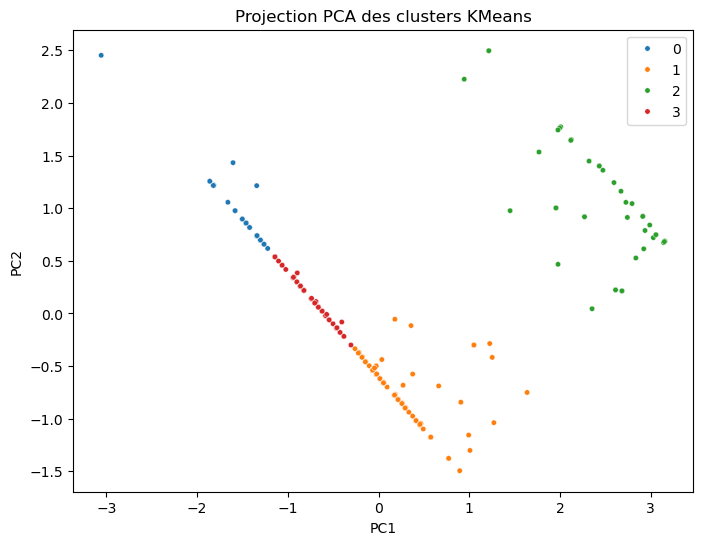

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10', s=15)
plt.title('Projection PCA des clusters KMeans')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Modèle supervisé : Prédiction de la sévérité

In [9]:
y = ml_df['severity'].astype(str)
X = ml_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
scaler_sup = StandardScaler()
X_train_scaled = scaler_sup.fit_transform(X_train)
X_test_scaled = scaler_sup.transform(X_test)
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

         nan       1.00      1.00      1.00        64

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



In [10]:
for f, imp in zip(features, model.feature_importances_):
    print(f'{f} : {imp:.3f}')


cvss : 0.000
epss : 0.000
